<a href="https://colab.research.google.com/github/ImSayvi/Sztuczna-Inteligencja/blob/main/21032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [3]:
observations = 10000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
inputs = (inputs - np.mean(inputs, axis=0)) / np.std(inputs, axis=0)
# normalizacja; potem trzeba odnormalzować
print(inputs.shape)

(10000, 2)


In [4]:
noise = np.random.uniform(low=-1,high=1, size=(observations,1))
targets = 4*xs - 44*zs + 6 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(10000, 1)


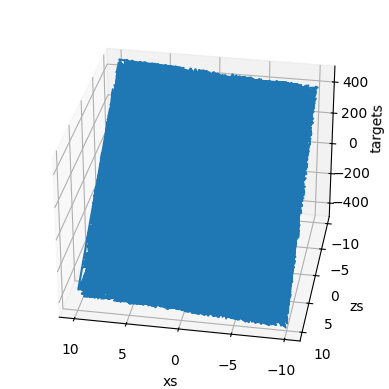

In [5]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('targets')
ax.view_init(azim=100)
plt.show()


In [6]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights,biases)

[[-0.01120646]
 [ 0.00672929]] [0.08243357]


In [7]:
targets = targets.reshape(observations,1)
eta = 0.01

for i in range (5000):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)
  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

32635.90879928974
31987.30829950524
31351.598770782937
30728.52398982823
30117.832826376904
29519.279141953666
28932.621690643216
28357.62402183401
27794.054384895408
27241.685635749818
26700.29514530207
26169.664709689267
25649.580462314723
25139.832787630683
24640.216236634948
24150.529444047384
23670.575047132945
23200.159606138386
22739.093526310637
22287.190981465475
21844.269839075492
21410.15158684732
20984.661260758436
20567.627374524498
20158.88185046888
19758.259951766377
19365.60021603393
18980.744390241434
18603.537366916524
18233.82712161748
17871.46465164918
17516.303915997272
17168.201776456397
16827.017939928748
16492.61490186964
16164.857890857369
15843.614814264858
15528.756205011434
15220.15516937301
14917.687335829765
14621.230804930678
14330.666100154713
14045.876119748775
13766.746089523103
13493.163516585031
13225.01814399243
12962.201906308606
12704.608886040694
12452.135270944009
12204.679312175107
11962.141283276711
11724.42343997797
11491.429980793808
11263.0

In [8]:
print(weights,biases)

[[  22.98999148]
 [-254.60147099]] [2.69900663]


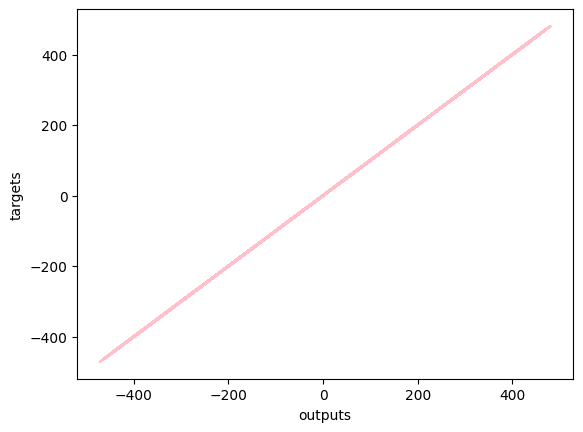

In [9]:
plt.plot(outputs, targets, color='pink')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

In [10]:
means = np.mean(np.column_stack((xs, zs)), axis=0)
stds = np.std(np.column_stack((xs, zs)), axis=0)

w1_norm = weights[0][0]
w2_norm = weights[1][0]

w1 = w1_norm / stds[0]
w2 = w2_norm / stds[1]

b = biases[0] - (w1_norm * means[0] / stds[0]) - (w2_norm * means[1] / stds[1])

#odnormalizowywuje xd
print(w1, w2, b)

3.999113547994486 -43.99810739536597 5.996016559914814
